Data Prep for EV Energy Consumption Dataset

## Step 1: Initial Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('data/raw/5-EV_Energy_Consumption_Dataset.csv')
print("Shape:", data.shape)
data.head()

Shape: (5000, 19)


,Vehicle_ID,Timestamp,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh
0,1102,2024-01-01 00:00:00,111.507366,-2.773816,30.415148,378.091525,25.314786,2,1,1,6.879446,4,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317
1,1435,2024-01-01 00:01:00,48.612323,-0.796982,97.385534,392.718377,18.240755,1,2,1,-3.007212,4,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701
2,1860,2024-01-01 00:02:00,108.733320,0.253800,84.912600,398.993495,44.449145,1,1,3,0.029585,1,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377
3,1270,2024-01-01 00:03:00,38.579484,-2.111395,28.777904,358.128273,28.980155,1,2,2,8.271943,3,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266
4,1106,2024-01-01 00:04:00,57.172438,1.477883,29.740160,310.888162,33.184551,2,1,1,2.776814,2,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205


In [3]:
print("--- Data Types ---")
print(data.dtypes)
print("\n--- Basic Statistics ---")
data.describe()

--- Data Types ---
Vehicle_ID                  int64
Timestamp                     str
Speed_kmh                 float64
Acceleration_ms2          float64
Battery_State_%           float64
Battery_Voltage_V         float64
Battery_Temperature_C     float64
Driving_Mode                int64
Road_Type                   int64
Traffic_Condition           int64
Slope_%                   float64
Weather_Condition           int64
Temperature_C             float64
Humidity_%                float64
Wind_Speed_ms             float64
Tire_Pressure_psi         float64
Vehicle_Weight_kg         float64
Distance_Travelled_km     float64
Energy_Consumption_kWh    float64
dtype: object

--- Basic Statistics ---


,Vehicle_ID,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1505.701200,59.312952,-0.019885,60.214465,351.118306,27.510130,2.011000,1.999200,2.010800,2.504690,2.48340,17.312654,55.302173,7.505087,31.503390,1854.719760,24.994042,8.437983
std,290.836902,34.517605,1.724287,23.128262,28.968372,10.015385,0.810068,0.808536,0.812167,4.360854,1.11372,13.005106,20.161289,4.325455,2.017357,373.685150,14.246454,2.184809
min,1000.000000,0.001396,-2.999683,20.020196,300.004812,10.003858,1.000000,1.000000,1.000000,-4.991079,1.00000,-4.995288,20.027119,0.000126,28.001891,1200.960317,0.107544,1.881426
25%,1253.000000,29.515400,-1.490240,40.088318,326.613439,18.884742,1.000000,1.000000,1.000000,-1.235653,1.00000,5.950476,37.970900,3.837738,29.772709,1531.417633,12.736568,6.771081
50%,1510.000000,58.646794,-0.043329,60.490283,351.510915,27.581710,2.000000,2.000000,2.000000,2.452368,2.00000,17.330798,55.650512,7.495373,31.484048,1865.006523,24.640458,8.455746
75%,1761.000000,89.030001,1.473887,80.409928,375.968140,35.920162,3.000000,3.000000,3.000000,6.366990,3.00000,28.624021,72.650838,11.291284,33.256528,2181.071491,37.562482,10.031938
max,1999.000000,119.946924,2.998039,99.993986,399.990098,44.985943,3.000000,3.000000,3.000000,9.998358,4.00000,39.998063,89.988891,14.999095,34.997829,2499.504564,49.993767,14.660528


## Step 2: Handling Missing Values

In [4]:
# Identify missing values per column
print("Missing values per column:")
print(data.isna().sum())
print(f"\nTotal missing: {data.isna().sum().sum()}")

Missing values per column:
Vehicle_ID                0
Timestamp                 0
Speed_kmh                 0
Acceleration_ms2          0
Battery_State_%           0
Battery_Voltage_V         0
Battery_Temperature_C     0
Driving_Mode              0
Road_Type                 0
Traffic_Condition         0
Slope_%                   0
Weather_Condition         0
Temperature_C             0
Humidity_%                0
Wind_Speed_ms             0
Tire_Pressure_psi         0
Vehicle_Weight_kg         0
Distance_Travelled_km     0
Energy_Consumption_kWh    0
dtype: int64

Total missing: 0


In [5]:
# Drop columns where more than 50% of values are missing
threshold = len(data) * 0.5
data_clean = data.dropna(thresh=threshold, axis=1)

# Drop non-informative columns: Vehicle_ID (identifier) and Timestamp (not used as a feature)
data_clean = data_clean.drop(columns=['Vehicle_ID', 'Timestamp'], errors='ignore')

# Impute remaining numeric columns with median
numeric_cols = data_clean.select_dtypes(include=np.number).columns
data_clean[numeric_cols] = data_clean[numeric_cols].fillna(data_clean[numeric_cols].median())

print("Missing values after imputation:")
print(data_clean.isna().sum())
print(f"\nShape after handling missing values: {data_clean.shape}")

Missing values after imputation:
Speed_kmh                 0
Acceleration_ms2          0
Battery_State_%           0
Battery_Voltage_V         0
Battery_Temperature_C     0
Driving_Mode              0
Road_Type                 0
Traffic_Condition         0
Slope_%                   0
Weather_Condition         0
Temperature_C             0
Humidity_%                0
Wind_Speed_ms             0
Tire_Pressure_psi         0
Vehicle_Weight_kg         0
Distance_Travelled_km     0
Energy_Consumption_kWh    0
dtype: int64

Shape after handling missing values: (5000, 17)


## Step 3: Dealing with Duplicates

In [6]:
print(f"Duplicate rows found: {data_clean.duplicated().sum()}")
data_clean = data_clean.drop_duplicates()
print(f"Shape after removing duplicates: {data_clean.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (5000, 17)


## Step 4: Handling Categorical Data

`Driving_Mode`, `Road_Type`, `Traffic_Condition`, and `Weather_Condition` are stored as integers but represent nominal categories — they need to be one-hot encoded.

In [7]:
# Cast integer-coded nominal columns to category type
nominal_cols = ['Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Weather_Condition']
for col in nominal_cols:
    data_clean[col] = data_clean[col].astype('category')

print("Category levels:")
for col in nominal_cols:
    print(f"  {col}: {sorted(data_clean[col].cat.categories.tolist())}")

# One-hot encode all nominal columns
data_encoded = pd.get_dummies(data_clean, columns=nominal_cols, drop_first=False)
print(f"\nShape after one-hot encoding: {data_encoded.shape}")
data_encoded.head()

Category levels:
  Driving_Mode: [1, 2, 3]
  Road_Type: [1, 2, 3]
  Traffic_Condition: [1, 2, 3]
  Weather_Condition: [1, 2, 3, 4]

Shape after one-hot encoding: (5000, 26)


,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Slope_%,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh,Driving_Mode_1,Driving_Mode_2,Driving_Mode_3,Road_Type_1,Road_Type_2,Road_Type_3,Traffic_Condition_1,Traffic_Condition_2,Traffic_Condition_3,Weather_Condition_1,Weather_Condition_2,Weather_Condition_3,Weather_Condition_4
0,111.507366,-2.773816,30.415148,378.091525,25.314786,6.879446,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317,False,True,False,True,False,False,True,False,False,False,False,False,True
1,48.612323,-0.796982,97.385534,392.718377,18.240755,-3.007212,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701,True,False,False,False,True,False,True,False,False,False,False,False,True
2,108.733320,0.253800,84.912600,398.993495,44.449145,0.029585,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377,True,False,False,True,False,False,False,False,True,True,False,False,False
3,38.579484,-2.111395,28.777904,358.128273,28.980155,8.271943,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266,True,False,False,False,True,False,False,True,False,False,False,True,False
4,57.172438,1.477883,29.740160,310.888162,33.184551,2.776814,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205,False,True,False,True,False,False,True,False,False,False,True,False,False


## Step 5: Data Manipulation & Outlier Management

In [8]:
# --- Discretization: bin Battery_State_% into meaningful charge groups ---
data_encoded['Charge_Level'] = pd.cut(
    data_encoded['Battery_State_%'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['Critical', 'Low', 'Moderate', 'Good', 'Full'],
    include_lowest=True
)
print("Charge Level distribution:")
print(data_encoded['Charge_Level'].value_counts().sort_index())

# --- Outlier Capping (±3 standard deviations) ---
# Only cap continuous numeric features; skip binary dummy columns
numeric_features = data_encoded.select_dtypes(include=np.number).columns.tolist()
exclude_cols = [c for c in numeric_features if data_encoded[c].nunique() <= 2]
cap_cols = [c for c in numeric_features if c not in exclude_cols]

outlier_counts = {}
for col in cap_cols:
    mean, std = data_encoded[col].mean(), data_encoded[col].std()
    lower, upper = mean - 3 * std, mean + 3 * std
    n_outliers = ((data_encoded[col] < lower) | (data_encoded[col] > upper)).sum()
    if n_outliers > 0:
        outlier_counts[col] = n_outliers
    data_encoded[col] = data_encoded[col].clip(lower, upper)

print(f"\nOutliers capped per column: {outlier_counts}")
print(f"Shape after outlier treatment: {data_encoded.shape}")

Charge Level distribution:
Charge_Level
Critical       0
Low         1243
Moderate    1223
Good        1255
Full        1279
Name: count, dtype: int64

Outliers capped per column: {'Energy_Consumption_kWh': np.int64(1)}
Shape after outlier treatment: (5000, 27)


## Step 6: Data Partitioning (Train/Test Split)

In [ ]:
# Drop derived columns not needed for modelling
df_model = data_encoded.drop(columns=['Charge_Level'])

X = df_model.drop(columns=['Energy_Consumption_kWh'])
y = df_model['Energy_Consumption_kWh']

# Stage 1: hold out 20% as the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Stage 2: split remainder into 75% train / 25% validation → 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set:    {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set:  {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:        {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTarget stats (train):\n{y_train.describe()}")

## Step 7: Feature Scaling

In [ ]:
# Scale only continuous numeric features (exclude binary dummy columns)
scale_cols = [c for c in X_train.select_dtypes(include=np.number).columns
              if X_train[c].nunique() > 2]

# --- Standardization (preferred: mean=0, std=1) ---
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

# Fit ONLY on training data, then transform all sets to prevent data leakage
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Standardization applied to:", scale_cols)
print(f"\nTrain feature means (should be ~0):\n{X_train_scaled[scale_cols].mean().round(4)}")
print(f"\nTrain feature std (should be ~1):\n{X_train_scaled[scale_cols].std().round(4)}")

# --- MinMax Normalization (for reference) ---
minmax = MinMaxScaler()
X_train_norm = X_train.copy()
X_val_norm   = X_val.copy()
X_test_norm  = X_test.copy()
X_train_norm[scale_cols] = minmax.fit_transform(X_train[scale_cols])
X_val_norm[scale_cols]   = minmax.transform(X_val[scale_cols])
X_test_norm[scale_cols]  = minmax.transform(X_test[scale_cols])
print(f"\nMinMax range check (train) — min:\n{X_train_norm[scale_cols].min().round(4)}")
print(f"MinMax range check (train) — max:\n{X_train_norm[scale_cols].max().round(4)}")

## Step 8: Visual Exploration

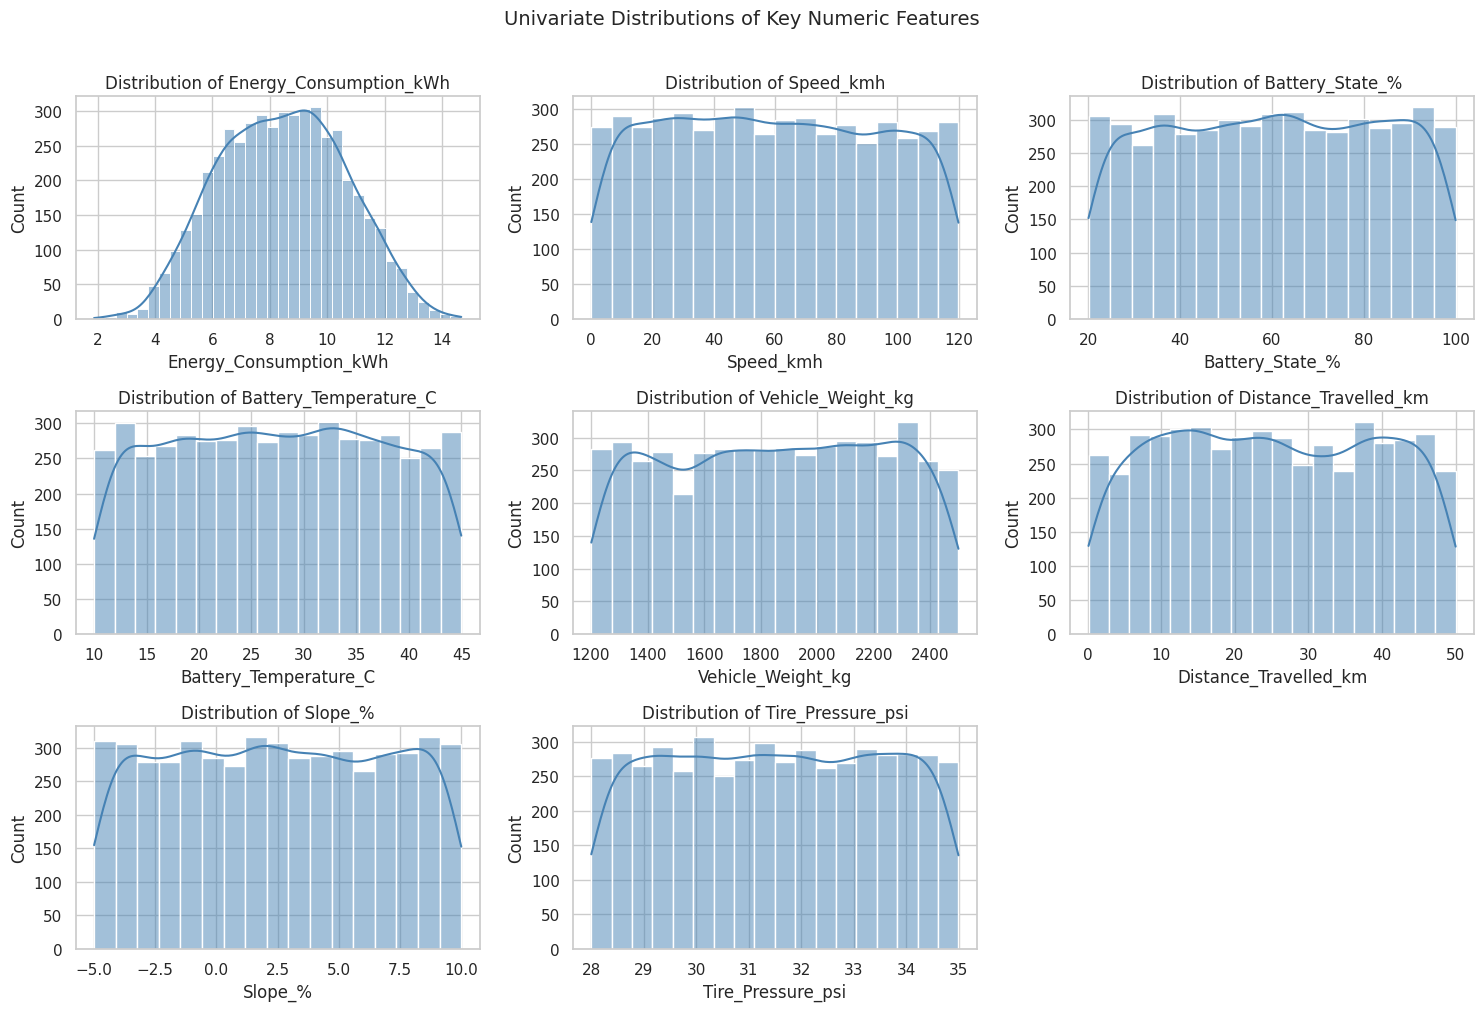

In [11]:
# --- Univariate: Distributions of key numeric features ---
cont_features = ['Energy_Consumption_kWh', 'Speed_kmh', 'Battery_State_%',
                 'Battery_Temperature_C', 'Vehicle_Weight_kg',
                 'Distance_Travelled_km', 'Slope_%', 'Tire_Pressure_psi']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cont_features):
    sns.histplot(data_clean[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

for j in range(len(cont_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions of Key Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

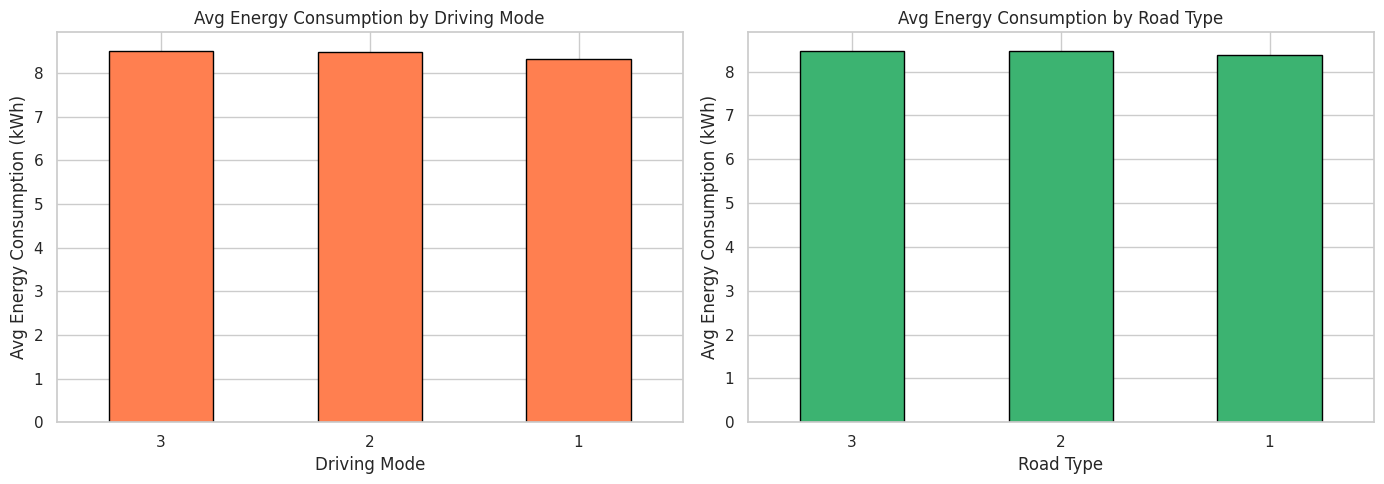

In [12]:
# --- Multivariate: Average Energy Consumption by Driving Mode and Road Type ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot: Average Energy Consumption by Driving Mode
driving_energy = data_clean.groupby('Driving_Mode')['Energy_Consumption_kWh'].mean().sort_values(ascending=False)
driving_energy.plot.bar(ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Avg Energy Consumption by Driving Mode')
axes[0].set_xlabel('Driving Mode')
axes[0].set_ylabel('Avg Energy Consumption (kWh)')
axes[0].tick_params(axis='x', rotation=0)

# Bar plot: Average Energy Consumption by Road Type
road_energy = data_clean.groupby('Road_Type')['Energy_Consumption_kWh'].mean().sort_values(ascending=False)
road_energy.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Avg Energy Consumption by Road Type')
axes[1].set_xlabel('Road Type')
axes[1].set_ylabel('Avg Energy Consumption (kWh)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

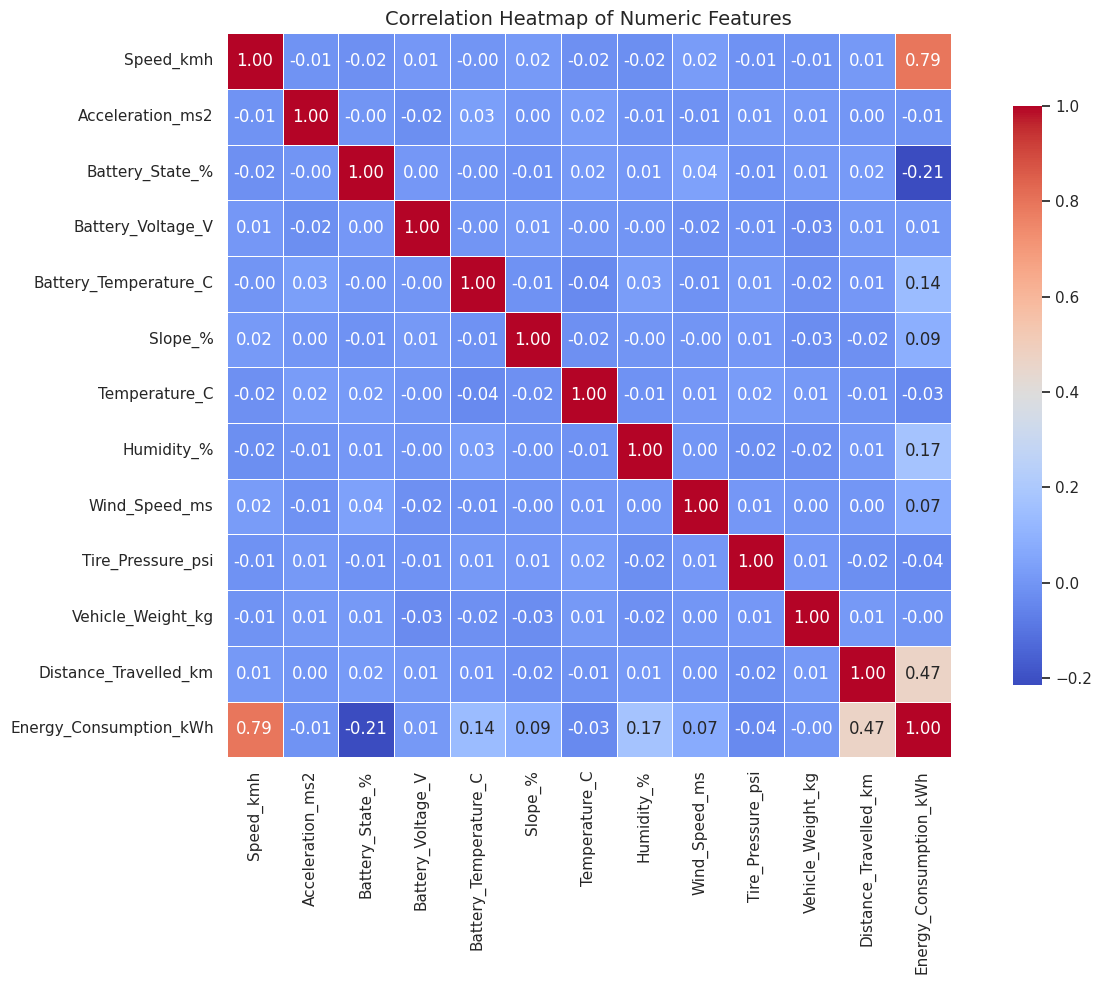

In [13]:
# --- Correlation Heatmap ---
numeric_cols_plot = ['Speed_kmh', 'Acceleration_ms2', 'Battery_State_%', 'Battery_Voltage_V',
                     'Battery_Temperature_C', 'Slope_%', 'Temperature_C', 'Humidity_%',
                     'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg',
                     'Distance_Travelled_km', 'Energy_Consumption_kWh']

corr = data_clean[numeric_cols_plot].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

## Export: Processed Dataset

### Use Case → Feature Mapping

| Use Case | Key Features | Target |
|---|---|---|
| **Predict EV Range** | `Battery_State_%`, `Battery_Voltage_V`, `Speed_kmh`, `Vehicle_Weight_kg`, `Slope_%`, `Temperature_C`, `Wind_Speed_ms`, `Distance_Travelled_km` | `Energy_Consumption_kWh` |
| **Optimize Driving Efficiency** | `Speed_kmh`, `Acceleration_ms2`, `Driving_Mode_*`, `Road_Type_*`, `Traffic_Condition_*`, `Slope_%` | `Energy_Consumption_kWh` |
| **Compare Driving Behaviors** | `Driving_Mode_*`, `Traffic_Condition_*`, `Speed_kmh`, `Acceleration_ms2`, `Road_Type_*` | `Energy_Consumption_kWh` |
| **Identify Performance Bottlenecks** | `Battery_Temperature_C`, `Battery_State_%`, `Battery_Voltage_V`, `Tire_Pressure_psi`, `Vehicle_Weight_kg` | `Energy_Consumption_kWh` |

The full encoded dataset is saved for flexible use across all four use cases. Scaled train/test splits are saved separately for direct model consumption.

In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

# --- Full processed dataset (encoded, outliers capped, continuous target) ---
# Excludes derived 'Charge_Level'; all model-ready columns retained
full_processed = data_encoded.drop(columns=['Charge_Level'], errors='ignore')
full_processed.to_csv('data/processed/5-EV_energy_consumption_processed.csv', index=False)
print(f"Saved full processed dataset: {full_processed.shape}")
print(f"Columns: {full_processed.columns.tolist()}")

In [ ]:
# --- Scaled train/validation/test splits (StandardScaler, leakage-free) ---
X_train_scaled.to_csv('data/processed/5-EV_energy_consumption_X_train.csv', index=False)
X_val_scaled.to_csv('data/processed/5-EV_energy_consumption_X_val.csv', index=False)
X_test_scaled.to_csv('data/processed/5-EV_energy_consumption_X_test.csv', index=False)
y_train.to_csv('data/processed/5-EV_energy_consumption_y_train.csv', index=False, header=True)
y_val.to_csv('data/processed/5-EV_energy_consumption_y_val.csv', index=False, header=True)
y_test.to_csv('data/processed/5-EV_energy_consumption_y_test.csv', index=False, header=True)

print("Saved train/validation/test splits:")
print(f"  X_train: {X_train_scaled.shape}  →  5-EV_energy_consumption_X_train.csv")
print(f"  X_val:   {X_val_scaled.shape}   →  5-EV_energy_consumption_X_val.csv")
print(f"  X_test:  {X_test_scaled.shape}   →  5-EV_energy_consumption_X_test.csv")
print(f"  y_train / y_val / y_test saved.")
print("\nTarget: Energy_Consumption_kWh (continuous — regression)")